# RBS versus Improved Ansatz on IBM Quantum Hardware — IBM-audited workflow

**Purpose:** optimize both XXZ ansätze locally, freeze the parameters, and compare only the final
circuits on a real IBM Quantum QPU.

Audited for the IBM Quantum Platform workflow current on **26 August 2026**:

- `qiskit == 2.5.2`
- `qiskit-ibm-runtime == 0.49.0`
- IBM Quantum Platform / IBM Quantum Compute Service
- `EstimatorV2` in **job mode** (compatible with Open Plan)

The noiseless benchmark is approximately

- RBS/Givens: \(E=-1.581819\)
- improved XY+ZZ: \(E=-1.616025\)
- exact ground state: \(E_0=-1.616025\)

> **The optimizer never runs on IBM hardware.**
>
> Optimize locally → freeze parameters → transpile to one real backend → submit the two frozen
> circuits together.

The hardware comparison is designed to control three major confounders:

1. both ansätze use the **same backend**;
2. both are initialized on the **same physical four-qubit path**;
3. both are submitted in the **same EstimatorV2 job**.

The hardware cell also refuses to submit unless it can explicitly identify an **Open Plan**
instance.


In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    name="default-ibm-quantum-platform"
)

job = service.job("da81133sq5js73bkh1a0")

print("Status:", job.status())

Status: DONE


In [1]:
pip install -U "qiskit==2.5.2" "qiskit-ibm-runtime==0.49.0"

Defaulting to user installation because normal site-packages is not writeable
  Using cached qiskit-2.5.2-cp310-abi3-win_amd64.whl.metadata (14 kB)
Using cached qiskit-2.5.2-cp310-abi3-win_amd64.whl (9.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import qiskit
import qiskit_ibm_runtime

print("Qiskit:", qiskit.__version__)
print("IBM Runtime:", qiskit_ibm_runtime.__version__)

Qiskit: 2.5.2
IBM Runtime: 0.49.0


In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService

print(QiskitRuntimeService.saved_accounts())

{'default-ibm-quantum-platform': {'channel': 'ibm_quantum_platform', 'url': 'https://cloud.ibm.com', 'token': '04Ck0GdweiriuyI4EeM-nCuG1Y-n4idKrfK1ZfRZEM9x', 'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/dbb5f83f98e14a94939ddcc10ca12efd:c763a1d1-825a-4d90-b011-acabab9e3cf1::', 'verify': True, 'private_endpoint': False}}


In [1]:
from getpass import getpass
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token=getpass("IBM Quantum API key:"),
    channel="ibm_quantum_platform",
    plans_preference=["open"],
    name="default-ibm-quantum-platform",
    overwrite=True,
)

print("IBM credential saved.")

KeyboardInterrupt: Interrupted by user

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

accounts = QiskitRuntimeService.saved_accounts()

print("Saved account names:")
for name in accounts.keys():
    print(name)

Saved account names:
default-ibm-quantum-platform


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    name="default-ibm-quantum-platform"
)

print("Connected successfully.")

Connected successfully.


In [4]:
instances = service.instances()

for x in instances:
    print(
        "Name:", x.get("name"),
        "| Plan:", x.get("plan")
    )

Name: open-instance | Plan: open


In [5]:
import sys, os
from importlib.metadata import version, PackageNotFoundError
import importlib.util

AUDITED_QISKIT = "2.5.2"
AUDITED_RUNTIME = "0.49.0"
IBM_ACCOUNT_NAME = "default-ibm-quantum-platform"

def _v(p):
    try:
        return version(p)
    except PackageNotFoundError:
        return "not installed"

print("Python             :", sys.version.split()[0])
print("qiskit             :", _v("qiskit"), f"(audited: {AUDITED_QISKIT})")
print("qiskit-ibm-runtime :", _v("qiskit-ibm-runtime"), f"(audited: {AUDITED_RUNTIME})")
for p in ["numpy", "scipy", "matplotlib", "pandas"]:
    print(f"{p:19s}:", _v(p))

HAS_RUNTIME = importlib.util.find_spec("qiskit_ibm_runtime") is not None
IBM_TOKEN = os.environ.get("IBM_QUANTUM_TOKEN", "").strip()

HAS_NAMED_IBM_ACCOUNT = False
if HAS_RUNTIME:
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService
        saved = QiskitRuntimeService.saved_accounts()
        HAS_NAMED_IBM_ACCOUNT = IBM_ACCOUNT_NAME in saved
    except Exception:
        HAS_NAMED_IBM_ACCOUNT = False

print(f"\nIBM runtime installed          : {HAS_RUNTIME}")
print(f"IBM token in environment       : {bool(IBM_TOKEN)}")
print(f"Saved account '{IBM_ACCOUNT_NAME}' : {HAS_NAMED_IBM_ACCOUNT}")

if _v("qiskit") != AUDITED_QISKIT:
    print(f"\nNOTE: this notebook was audited with qiskit {AUDITED_QISKIT}.")
if HAS_RUNTIME and _v("qiskit-ibm-runtime") != AUDITED_RUNTIME:
    print(f"NOTE: this notebook was audited with qiskit-ibm-runtime {AUDITED_RUNTIME}.")


Python             : 3.14.6
qiskit             : 2.5.2 (audited: 2.5.2)
qiskit-ibm-runtime : 0.49.0 (audited: 0.49.0)
numpy              : 2.4.6
scipy              : 1.18.0
matplotlib         : 3.11.1
pandas             : 3.0.3

IBM runtime installed          : True
IBM token in environment       : False
Saved account 'default-ibm-quantum-platform' : True


In [6]:
backends = service.backends(
    operational=True,
    simulator=False
)

for b in backends:
    print(
        b.name,
        "| qubits:", b.num_qubits,
        "| pending jobs:", b.status().pending_jobs
    )

ibm_fez | qubits: 156 | pending jobs: 6
ibm_marrakesh | qubits: 156 | pending jobs: 6
ibm_kingston | qubits: 156 | pending jobs: 39


In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    name="default-ibm-quantum-platform"
)

backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=4
)

print("Selected backend:", backend.name)
print("Number of qubits:", backend.num_qubits)
print("Pending jobs:", backend.status().pending_jobs)
print("Operational:", backend.status().operational)

Selected backend: ibm_marrakesh
Number of qubits: 156
Pending jobs: 6
Operational: True


In [8]:
for x in service.instances():
    print(
        "Name:", x.get("name"),
        "| Plan:", x.get("plan"),
        "| CRN:", x.get("crn")
    )

Name: open-instance | Plan: open | CRN: crn:v1:bluemix:public:quantum-computing:us-east:a/dbb5f83f98e14a94939ddcc10ca12efd:c763a1d1-825a-4d90-b011-acabab9e3cf1::


In [12]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.circuit.library import XXPlusYYGate, RZZGate
from qiskit.primitives import StatevectorEstimator

# ----------------------------- configuration -----------------------------
L        = 4        # keep small: fewer qubits, shallower circuits, less noise
J, DELTA = 1.0, 1.0
DEPTH    = 3
SEED     = 12345
SHOTS    = 4096
RESTARTS = 6
BASIS    = ["rz","sx","x","cx"]
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi":110,"font.size":10})
print(f"L={L}, depth={DEPTH}, shots={SHOTS}")

L=4, depth=2, shots=4096


## 1. Hamiltonian and exact benchmark

$$H=\frac{J}{4}\sum_{i=0}^{L-2}\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta Z_iZ_{i+1}\big)$$

with $S^\alpha=\sigma^\alpha/2$. Qiskit is little-endian, so a Pauli letter for qubit $q$ sits
at string position $L-1-q$ — getting this backwards mirrors the chain and hides the bug in the
energy.

In [14]:
def pauli_label(pairs, N):
    ch=["I"]*N
    for q,P in pairs: ch[N-1-q]=P
    return "".join(ch)

def xxz_hamiltonian(N, J=J, delta=DELTA):
    terms=[]
    for i in range(N-1):
        terms += [(pauli_label([(i,"X"),(i+1,"X")],N), J/4),
                  (pauli_label([(i,"Y"),(i+1,"Y")],N), J/4),
                  (pauli_label([(i,"Z"),(i+1,"Z")],N), J*delta/4)]
    lab,cf=zip(*terms)
    return SparsePauliOp(list(lab), np.array(cf))

H=xxz_hamiltonian(L); Hm=H.to_matrix()
E_EXACT=float(np.linalg.eigvalsh(Hm)[0].real)
PSI_EXACT=np.linalg.eigh(Hm)[1][:,0]
E_HF=-1.5818190387                      # the RBS ceiling, from the companion study
print(f"{len(H)} Pauli terms to measure per circuit")
print(f"exact ground-state energy : {E_EXACT:.10f}")
print(f"Hartree-Fock ceiling      : {E_HF:.10f}")
print(f"correlation energy (gap)  : {abs(E_EXACT-E_HF):.6f}   <- what a hardware run must resolve")
assert abs(E_EXACT-(-1.6160254038))<1e-8

9 Pauli terms to measure per circuit
exact ground-state energy : -1.6160254038
Hartree-Fock ceiling      : -1.5818190387
correlation energy (gap)  : 0.034206   <- what a hardware run must resolve


## 2. The two ansätze — represented in hardware-aware high-level gates

**RBS / Givens** — a real rotation in the \(|01\rangle,|10\rangle\) subspace, starting from a
Néel product state. Rather than hard-coding one particular CNOT decomposition, the IBM-oriented
version represents it as

\[
G(\theta)=\mathrm{XXPlusYYGate}(2\theta,\beta=\pi/2),
\]

which is exactly the target real Givens matrix. This leaves the final native synthesis to the
backend-aware Qiskit transpiler.

**Improved XY+ZZ** — combines number-conserving \(XY\) hopping with an interacting \(ZZ\) phase.
The \(ZZ\) block is represented directly as

\[
R_{ZZ}(\beta/2)=e^{-i\beta ZZ/4},
\]

again leaving backend-specific decomposition to the transpiler. On a conventional IBM target it
will be decomposed as needed; on a suitable Heron target with fractional gates enabled, the same
high-level representation can expose native fractional `rzz`.

The improved reference is the reflection-symmetric superposition of the two Néel configurations.
It is prepared as a **nearest-neighbour GHZ chain**, which is state-equivalent to the original star
preparation but better matched to sparse hardware connectivity.


In [15]:
def givens_gate(theta):
    # Exact real Givens/RBS rotation:
    # XXPlusYYGate(2*theta, beta=pi/2) gives
    # [[1,0,0,0],[0,c,-s,0],[0,s,c,0],[0,0,0,1]]
    qc=QuantumCircuit(2,name="G")
    qc.append(XXPlusYYGate(2*theta, beta=np.pi/2), [0,1])
    return qc

def xy_gate(alpha):
    qc=QuantumCircuit(2,name="XY")
    qc.append(XXPlusYYGate(alpha), [0,1])
    return qc

def zz_gate(beta):
    # RZZ(phi) = exp(-i phi ZZ / 2); choose phi=beta/2 -> exp(-i beta ZZ / 4)
    qc=QuantumCircuit(2,name="ZZ")
    qc.append(RZZGate(beta/2), [0,1])
    return qc

# verify every gate against its analytic target before trusting it on hardware
def givens_target(t):
    c,s=np.cos(t),np.sin(t)
    return np.array([[1,0,0,0],[0,c,-s,0],[0,s,c,0],[0,0,0,1]],dtype=complex)
def xy_target(a):
    c,s=np.cos(a/2),np.sin(a/2)
    return np.array([[1,0,0,0],[0,c,-1j*s,0],[0,-1j*s,c,0],[0,0,0,1]],dtype=complex)
def zz_target(b):
    d=np.array([1.,-1.,-1.,1.]); return np.diag(np.exp(-1j*b*d/4))

rng=np.random.default_rng(SEED); worst={}
for nm,fn,tg in [("Givens",givens_gate,givens_target),("XY",xy_gate,xy_target),("ZZ",zz_gate,zz_target)]:
    worst[nm]=max(np.linalg.norm(Operator(fn(t)).data-tg(t)) for t in rng.uniform(-np.pi,np.pi,8))
for k,v in worst.items(): print(f"max ||U_circuit - U_target||  {k:7s}: {v:.2e}")
assert all(v<1e-10 for v in worst.values())
print("\nall gates VERIFIED")

max ||U_circuit - U_target||  Givens : 8.57e-17
max ||U_circuit - U_target||  XY     : 0.00e+00
max ||U_circuit - U_target||  ZZ     : 0.00e+00

all gates VERIFIED


In [16]:
def brickwall(N,depth):
    b=[]
    for _ in range(depth): b += list(range(0,N-1,2))+list(range(1,N-1,2))
    return b

def rbs_ansatz(params, N=L, depth=DEPTH):
    qc=QuantumCircuit(N)
    for q in range(0,N,2): qc.x(q)                  # Neel reference
    qc.barrier()
    for t,i in zip(params, brickwall(N,depth)):
        qc.compose(givens_gate(t), qubits=[i,i+1], inplace=True)
    return qc

def symmetric_reference(N, sign=+1):
    # (|0101...> + sign |1010...>)/sqrt(2), prepared with NN entanglers
    qc=QuantumCircuit(N)
    qc.h(0)
    if sign < 0:
        qc.z(0)
    for q in range(N-1):
        qc.cx(q, q+1)
    for q in range(1, N, 2):
        qc.x(q)
    return qc

def improved_ansatz(params, N=L, depth=DEPTH, sign=+1):
    qc=symmetric_reference(N,sign); qc.barrier()
    even,odd=list(range(0,N-1,2)),list(range(1,N-1,2)); k=0
    for _ in range(depth):
        for grp in (even,odd):
            for i in grp: qc.compose(xy_gate(params[k]),qubits=[i,i+1],inplace=True); k+=1
            for i in grp: qc.compose(zz_gate(params[k]),qubits=[i,i+1],inplace=True); k+=1
        qc.barrier()
    return qc

def n_params(kind,N=L,depth=DEPTH):
    return depth*(N-1) if kind=="rbs" else 2*depth*(N-1)

print(f"RBS parameters      : {n_params('rbs')}")
print(f"improved parameters : {n_params('imp')}\n")
print(rbs_ansatz(np.linspace(0.2,1.0,n_params('rbs'))).draw(output="text",fold=130))

# --- self-test: chain reference must be exactly equivalent to the original star preparation ---
def _star_reference_for_test(N, sign=+1):
    qc=QuantumCircuit(N)
    qc.h(0)
    if sign < 0:
        qc.z(0)
    for q in range(1,N):
        if q % 2 == 1:
            qc.x(q)
        qc.cx(0,q)
    return qc

for _sgn in (+1,-1):
    v_star = np.asarray(Statevector(_star_reference_for_test(L,_sgn)).data)
    v_chain = np.asarray(Statevector(symmetric_reference(L,_sgn)).data)
    overlap = abs(np.vdot(v_star,v_chain))
    assert abs(overlap-1.0) < 1e-12, "NN reference preparation changed the physical state"

print("reference-state equivalence VERIFIED: star == NN chain (up to global phase)")


RBS parameters      : 6
improved parameters : 12

     ┌───┐ ░ ┌───────────────────┐                       ┌────────────────────┐                   
q_0: ┤ X ├─░─┤0                  ├───────────────────────┤0                   ├───────────────────
     └───┘ ░ │  (XX+YY)(0.4,π/2) │ ┌────────────────────┐│  (XX+YY)(1.36,π/2) │┌─────────────────┐
q_1: ──────░─┤1                  ├─┤0                   ├┤1                   ├┤0                ├
     ┌───┐ ░ ├───────────────────┴┐│  (XX+YY)(1.04,π/2) │├────────────────────┤│  (XX+YY)(2,π/2) │
q_2: ┤ X ├─░─┤0                   ├┤1                   ├┤0                   ├┤1                ├
     └───┘ ░ │  (XX+YY)(0.72,π/2) │└────────────────────┘│  (XX+YY)(1.68,π/2) │└─────────────────┘
q_3: ──────░─┤1                   ├──────────────────────┤1                   ├───────────────────
           ░ └────────────────────┘                      └────────────────────┘                   
reference-state equivalence VERIFIED: star == NN chain (up 

## 3. Optimize on the simulator, then freeze

This is the only place an optimizer runs. For the improved ansatz both reference signs are
tried and the lower energy kept — safe by the variational principle.

In [17]:
est=StatevectorEstimator()
def energy(qc): return float(est.run([(qc,H)]).result()[0].data.evs)

# --- RBS ---
best_r=None
for r in range(RESTARTS):
    x0=np.random.default_rng(SEED+137*r).normal(0,0.8,n_params("rbs"))
    res=minimize(lambda x: energy(rbs_ansatz(x)), x0, method="COBYLA",
                 options={"maxiter":2000,"rhobeg":0.5,"tol":1e-12})
    if best_r is None or res.fun<best_r.fun: best_r=res
X_RBS=best_r.x; E_RBS=float(best_r.fun)

# --- improved, both parities ---
best_i=None
for sgn in (+1,-1):
    for r in range(RESTARTS):
        x0=np.random.default_rng(SEED+911*r).normal(0,1.0,n_params("imp"))
        res=minimize(lambda x,s=sgn: energy(improved_ansatz(x,sign=s)), x0, method="COBYLA",
                     options={"maxiter":2500,"rhobeg":0.5,"tol":1e-12})
        if best_i is None or res.fun<best_i[0]: best_i=(float(res.fun),res.x.copy(),sgn)
E_IMP,X_IMP,SIGN=best_i

F_R=float(abs(np.vdot(PSI_EXACT,np.asarray(Statevector(rbs_ansatz(X_RBS)).data)))**2)
F_I=float(abs(np.vdot(PSI_EXACT,np.asarray(Statevector(improved_ansatz(X_IMP,sign=SIGN)).data)))**2)
print(f"{'':18s}{'energy':>14}{'error':>13}{'fidelity':>12}")
print(f"{'exact':18s}{E_EXACT:>14.8f}{0.0:>13.8f}{1.0:>12.6f}")
print(f"{'RBS':18s}{E_RBS:>14.8f}{E_RBS-E_EXACT:>13.8f}{F_R:>12.6f}")
print(f"{'improved':18s}{E_IMP:>14.8f}{E_IMP-E_EXACT:>13.8f}{F_I:>12.6f}")
print(f"\nimproved reference sign: {SIGN:+d}")
assert E_RBS>=E_EXACT-1e-9 and E_IMP>=E_EXACT-1e-9, "variational bound violated"
print("\nPARAMETERS FROZEN -- nothing below re-optimizes.")

                          energy        error    fidelity
exact                -1.61602540   0.00000000    1.000000
RBS                  -1.58181904   0.03420637    0.984642
improved             -1.61602540  -0.00000000    1.000000

improved reference sign: +1

PARAMETERS FROZEN -- nothing below re-optimizes.


## 4. Topology-normalized CX-basis proxy

This section is a **local diagnostic only**. It transpiles both frozen circuits to the same
illustrative linear `rz/sx/x/cx` basis so that their logical/topological cost can be compared on
equal footing.

It is **not** the final IBM hardware gate count. Real IBM QPUs can have different native
two-qubit instructions, so Section 6 recompiles directly against the selected backend and counts
the actual native nonlocal gates.


,ansatz,parameters,transpiled_depth,cx,one_qubit,noiseless_error,fidelity
0,RBS,6,39,12,80,0.034206,0.984642
1,improved,12,50,21,86,-0.000000,1.000000


the improved circuit uses 1.75x the CX gates of RBS
and buys an accuracy gain of 3.42e+13x -- noiselessly


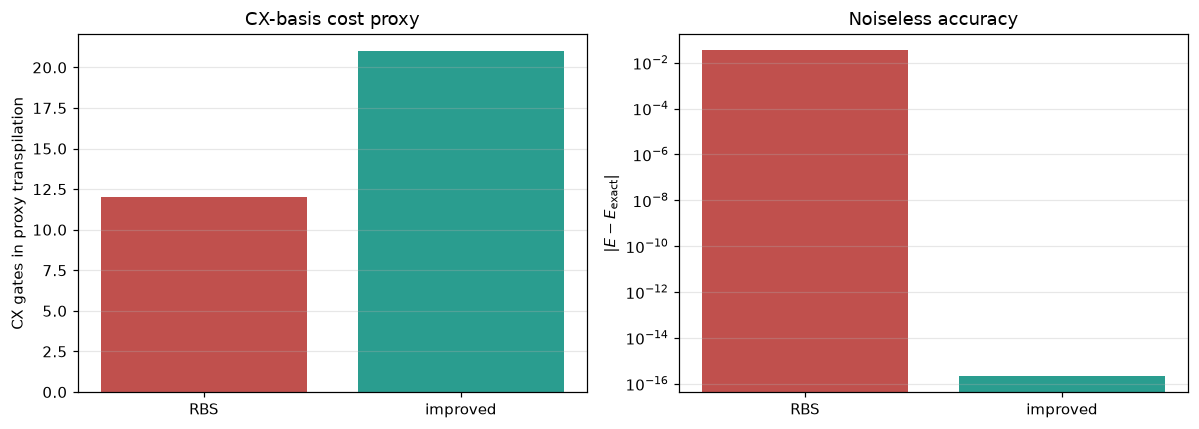

In [18]:
coupling=[[i,i+1] for i in range(L-1)]+[[i+1,i] for i in range(L-1)]
qc_rbs=rbs_ansatz(X_RBS); qc_imp=improved_ansatz(X_IMP,sign=SIGN)

rows=[]
for lab,qc,err,fid in [("RBS",qc_rbs,E_RBS-E_EXACT,F_R),
                       ("improved",qc_imp,E_IMP-E_EXACT,F_I)]:
    tq=transpile(qc,basis_gates=BASIS,coupling_map=coupling,optimization_level=3,
                 seed_transpiler=SEED)
    ops=dict(tq.count_ops())
    rows.append(dict(ansatz=lab, parameters=qc.num_parameters or len(X_RBS if lab=="RBS" else X_IMP),
                     transpiled_depth=tq.depth(), cx=ops.get("cx",0),
                     one_qubit=sum(v for k,v in ops.items() if k not in ("cx","barrier")),
                     noiseless_error=err, fidelity=fid))
df=pd.DataFrame(rows); display(df.round(8))
ratio=df.loc[1,"cx"]/max(df.loc[0,"cx"],1)
print(f"the improved circuit uses {ratio:.2f}x the CX gates of RBS")
print(f"and buys an accuracy gain of {abs(df.loc[0,'noiseless_error'])/max(abs(df.loc[1,'noiseless_error']),1e-15):.2e}x -- noiselessly")

fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].bar(df.ansatz,df.cx,color=["#c0504d","#2a9d8f"])
ax[0].set_ylabel("CX gates in proxy transpilation"); ax[0].set_title("CX-basis cost proxy")
ax[1].bar(df.ansatz,np.maximum(np.abs(df.noiseless_error),1e-17),color=["#c0504d","#2a9d8f"])
ax[1].set_yscale("log"); ax[1].set_ylabel(r"$|E-E_{\rm exact}|$")
ax[1].set_title("Noiseless accuracy")
for a in ax: a.grid(alpha=.3,axis="y")
plt.tight_layout(); plt.show()

## 5. Will the shot budget resolve the noiseless energy gap?

This is a **shot-noise-only sanity check**, not a prediction of IBM hardware uncertainty.

The noiseless ansätze differ by about

\[
|E_{\rm exact}-E_{\rm RBS}| \simeq 0.0342 .
\]

The simulation below asks whether finite sampling alone is already comparable to that scale.
`EstimatorV2` can internally group compatible observables, so do not interpret the local
`shots × number-of-Pauli-terms` count as an exact estimate of IBM QPU usage.


,shots_per_term,mean,std,total_shots
0,256,-1.603516,0.017027,2304
1,1024,-1.610254,0.010304,9216
2,4096,-1.623950,0.007990,36864


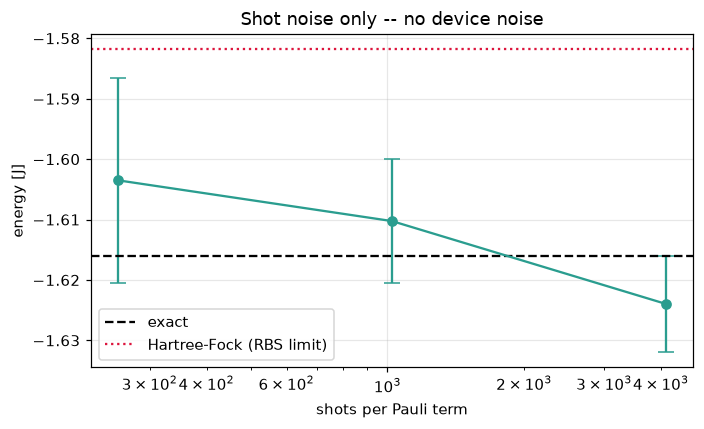

gap to resolve: 0.0342
If the error bars straddle both dashed lines, more shots are needed before a QPU run
can distinguish the two ansaetze.


In [19]:
def sampled_energy(qc, shots, rng):
    """Energy from simulated sampling -- basis-rotate each Pauli term, sample, average."""
    total=0.0
    for pstr,coeff in zip(H.paulis.to_labels(), H.coeffs.real):
        m=qc.copy()
        for pos,P in enumerate(pstr):
            q=L-1-pos
            if P=="X": m.h(q)
            elif P=="Y": m.sdg(q); m.h(q)
        probs=np.abs(np.asarray(Statevector(m).data))**2
        probs=np.clip(probs,0,None); probs/=probs.sum()
        idx=rng.choice(len(probs),size=shots,p=probs)
        sign=np.array([1.0-2.0*(bin(i & int("".join("1" if p!="I" else "0" for p in pstr),2)).count("1")%2)
                       for i in idx])
        total += coeff*sign.mean()
    return total

rng=np.random.default_rng(SEED)
rows=[]
for shots in [256,1024,4096]:
    v=np.array([sampled_energy(qc_imp,shots,rng) for _ in range(5)])
    rows.append(dict(shots_per_term=shots, mean=v.mean(), std=v.std(),
                     total_shots=shots*len(H)))
df_s=pd.DataFrame(rows); display(df_s.round(6))
gap=abs(E_EXACT-E_HF)
fig,ax=plt.subplots(figsize=(6.5,4))
ax.errorbar(df_s.shots_per_term,df_s["mean"],yerr=df_s["std"],fmt="o-",capsize=5,color="#2a9d8f")
ax.axhline(E_EXACT,ls="--",c="k",label="exact")
ax.axhline(E_HF,ls=":",c="crimson",label="Hartree-Fock (RBS limit)")
ax.set_xscale("log"); ax.set_xlabel("shots per Pauli term"); ax.set_ylabel("energy [J]")
ax.set_title("Shot noise only -- no device noise"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"gap to resolve: {gap:.4f}")
print("If the error bars straddle both dashed lines, more shots are needed before a QPU run")
print("can distinguish the two ansaetze.")

## 6. Run the frozen circuits on IBM hardware

### A. Install the versions audited by this notebook

Run once:

```python
%pip install -U "qiskit==2.5.2" "qiskit-ibm-runtime==0.49.0"
```

Then **restart the Jupyter kernel** and run the notebook from the top.

### B. Save a dedicated Open-Plan credential profile

Use a named profile so this notebook does not accidentally inherit a different saved instance:

```python
from getpass import getpass
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token=getpass("IBM Quantum API key: "),
    channel="ibm_quantum_platform",
    plans_preference=["open"],
    name="ibm_open_plan",
    overwrite=True,
)
```

The API key is hidden by `getpass` and is not written into notebook output.

### Why the hardware cell performs another Open-Plan check

`plans_preference=["open"]` is useful, but IBM documents that plan preference is ignored when an
explicit instance is already fixed in an account configuration. Therefore the hardware cell does
**not** trust preference alone. It:

1. lists the instances available to the account;
2. finds an instance whose plan is explicitly `open`;
3. extracts that instance's CRN;
4. reinitializes the service against that exact CRN;
5. submits the job only through that explicit Open Plan instance.

If no Open Plan instance is found, the cell raises an error **before submission**.

### Baseline hardware protocol

The first experiment intentionally uses the conventional backend target
(`use_fractional_gates=False`) and turns off Runtime mitigation/suppression so that the result is a
clean raw baseline. Fractional `RZZ` is a separate follow-up experiment.


In [17]:
if not HAS_RUNTIME:
    raise RuntimeError(
        'qiskit-ibm-runtime is not installed. Run '
        '%pip install -U "qiskit==2.5.2" "qiskit-ibm-runtime==0.49.0", '
        'restart the kernel, and rerun from the top.'
    )

import numpy as np
from collections import defaultdict
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# -------------------------------------------------------------------------
# 1. DISCOVER THE ACCOUNT, THEN EXPLICITLY PIN AN OPEN PLAN INSTANCE.
# -------------------------------------------------------------------------
if IBM_TOKEN:
    discovery = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=IBM_TOKEN,
        plans_preference=["open"],
    )
elif HAS_NAMED_IBM_ACCOUNT:
    discovery = QiskitRuntimeService(name=IBM_ACCOUNT_NAME)
else:
    raise RuntimeError(
        f"No IBM credential found. Save the named account '{IBM_ACCOUNT_NAME}' "
        "with the setup cell above, or define IBM_QUANTUM_TOKEN."
    )

instances = discovery.instances()
if not instances:
    raise RuntimeError("IBM account is valid, but no Quantum service instances were returned.")

def _is_open_plan(info):
    return "open" in str(info.get("plan", "")).strip().lower()

open_instances = [info for info in instances if _is_open_plan(info)]
if not open_instances:
    available = [(x.get("name"), x.get("plan")) for x in instances]
    raise RuntimeError(
        "NO OPEN PLAN INSTANCE FOUND. Nothing was submitted.\n"
        f"Available instances (name, plan): {available}"
    )

# Usually there is one Open instance. If several exist, use the first explicit Open CRN.
open_info = open_instances[0]
OPEN_CRN = open_info.get("crn")
if not OPEN_CRN:
    raise RuntimeError("An Open Plan instance was found, but its CRN was missing.")

print("Open Plan instance:")
print("  name :", open_info.get("name"))
print("  plan :", open_info.get("plan"))
print("  CRN  :", OPEN_CRN)

# Reinitialize against the exact Open instance. This removes ambiguity from saved defaults.
if IBM_TOKEN:
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=IBM_TOKEN,
        instance=OPEN_CRN,
    )
else:
    service = QiskitRuntimeService(
        name=IBM_ACCOUNT_NAME,
        instance=OPEN_CRN,
    )

# -------------------------------------------------------------------------
# 2. SELECT A REAL, OPERATIONAL BACKEND IN THAT EXACT OPEN INSTANCE.
#    Fractional gates are OFF for the reproducible raw baseline.
# -------------------------------------------------------------------------
backend = service.least_busy(
    instance=OPEN_CRN,
    operational=True,
    simulator=False,
    min_num_qubits=L,
    use_fractional_gates=False,
)

status = backend.status()
if not status.operational:
    raise RuntimeError(f"Selected backend {backend.name} is not operational.")

print("\nbackend:", backend.name)
print("pending jobs:", getattr(status, "pending_jobs", "unknown"))
print("status message:", getattr(status, "status_msg", "unknown"))
print("active instance:", service.active_instance())

# Verify that the service is still pinned to the Open CRN.
active_crn = service.active_instance()
if active_crn != OPEN_CRN:
    raise RuntimeError(
        "SAFETY STOP: active IBM instance differs from the explicitly selected Open Plan CRN. "
        "Nothing has been submitted."
    )

# Open-plan quota check.
try:
    usage = service.usage()
    print("Open Plan usage:", usage)
    remaining = usage.get("usage_remaining_seconds")
    if remaining is not None and float(remaining) <= 0:
        raise RuntimeError("Open Plan QPU allowance is exhausted. Nothing was submitted.")
except RuntimeError:
    raise
except Exception as exc:
    print("WARNING: could not read usage quota:", exc)

# -------------------------------------------------------------------------
# 3. INSPECT NATIVE 2-QUBIT OPERATIONS AND CHOOSE A LOW-ERROR 4-QUBIT PATH.
# -------------------------------------------------------------------------
def _native_2q_names(be):
    names = []
    for name in be.target.operation_names:
        try:
            op = be.target.operation_from_name(name)
            if getattr(op, "num_qubits", None) == 2:
                names.append(name)
        except Exception:
            pass
    return sorted(set(names))

native_2q = _native_2q_names(backend)
if not native_2q:
    raise RuntimeError("No native two-qubit operations were found in backend.target.")

print("\nnative 2Q instructions:", native_2q)

def _edge_error(be, a, b, twoq_names):
    vals = []
    for name in twoq_names:
        try:
            props = be.target[name]
        except Exception:
            continue
        for pair in ((a, b), (b, a)):
            try:
                prop = props[pair]
                err = getattr(prop, "error", None)
                if err is not None and np.isfinite(float(err)):
                    vals.append(float(err))
            except Exception:
                pass
    return min(vals) if vals else 1.0

def best_connected_path(be, n):
    if be.coupling_map is None:
        raise RuntimeError("Backend coupling map is unavailable.")

    adj = defaultdict(set)
    for a, b in be.coupling_map.get_edges():
        adj[int(a)].add(int(b))
        adj[int(b)].add(int(a))

    best = None
    for start in adj:
        stack = [(start, [start])]
        while stack:
            node, path = stack.pop()

            if len(path) == n:
                score = sum(
                    _edge_error(be, path[k], path[k+1], native_2q)
                    for k in range(n-1)
                )
                if best is None or score < best[0]:
                    best = (score, path.copy())
                continue

            for nxt in adj[node]:
                if nxt not in path:
                    stack.append((nxt, path + [nxt]))

    if best is None:
        raise RuntimeError(f"No connected physical path of length {n} was found.")
    return best

path_score, physical_path = best_connected_path(backend, L)

print("chosen physical path:", physical_path)
print(f"summed best 2Q edge-error proxy: {path_score:.6e}")

# -------------------------------------------------------------------------
# 4. TRANSPILE BOTH CIRCUITS WITH THE SAME BACKEND AND SAME INITIAL LAYOUT.
# -------------------------------------------------------------------------
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
    seed_transpiler=SEED,
    initial_layout=physical_path,
)

circuits = {
    "RBS": qc_rbs,
    "improved": qc_imp,
}

isa = {}
mapped_obs = {}
hardware_metrics = {}

for label, qc in circuits.items():
    isa[label] = pm.run(qc)
    mapped_obs[label] = H.apply_layout(isa[label].layout)

    ops = dict(isa[label].count_ops())
    twoq_insts = [inst for inst in isa[label].data if len(inst.qubits) == 2]
    twoq_total = len(twoq_insts)

    used_2q_physical_qubits = sorted({
        isa[label].find_bit(q).index
        for inst in twoq_insts
        for q in inst.qubits
    })

    # For this nearest-neighbour problem, routing outside the selected 4-qubit path is unnecessary.
    # Refuse to make an unfair comparison if the transpiler unexpectedly uses extra qubits.
    if not set(used_2q_physical_qubits).issubset(set(physical_path)):
        raise RuntimeError(
            f"{label} transpilation routed two-qubit operations outside the common physical path. "
            f"Path={physical_path}, used={used_2q_physical_qubits}. Nothing was submitted."
        )

    native_breakdown = {
        name: ops.get(name, 0)
        for name in native_2q
        if ops.get(name, 0)
    }

    hardware_metrics[label] = {
        "depth": isa[label].depth(),
        "twoq_total": twoq_total,
        "twoq_breakdown": native_breakdown,
        "twoq_physical_qubits": used_2q_physical_qubits,
    }

    print(
        f"\n{label:8s}: depth={isa[label].depth():4d}, "
        f"native 2Q total={twoq_total:3d}, "
        f"2Q breakdown={native_breakdown}"
    )
    print("           2Q physical qubits:", used_2q_physical_qubits)

# Final fairness assertion before any QPU submission.
if set(hardware_metrics["RBS"]["twoq_physical_qubits"]) != set(
    hardware_metrics["improved"]["twoq_physical_qubits"]
):
    raise RuntimeError(
        "FAIRNESS STOP: the two transpiled circuits do not use the same set of physical "
        "two-qubit locations. Nothing was submitted."
    )

# -------------------------------------------------------------------------
# 5. RAW BASELINE ESTIMATOR CONFIGURATION.
# -------------------------------------------------------------------------
estimator = EstimatorV2(mode=backend)
estimator.options.default_shots = SHOTS
estimator.options.resilience_level = 0

# Explicitly disable suppression/mitigation features for the raw baseline.
estimator.options.twirling.enable_gates = False
estimator.options.twirling.enable_measure = False
estimator.options.dynamical_decoupling.enable = False

pubs = [
    (isa["RBS"], mapped_obs["RBS"]),
    (isa["improved"], mapped_obs["improved"]),
]

print("\nPRE-SUBMISSION CHECK PASSED")
print("  plan      : OPEN")
print("  backend   :", backend.name)
print("  instance  :", OPEN_CRN)
print("  shots/PUB :", SHOTS)
print("  PUBs      : 2")
print("  mitigation: OFF (raw baseline)")

# -------------------------------------------------------------------------
# 6. THIS IS THE ONLY LINE THAT SUBMITS TO THE QPU.
# -------------------------------------------------------------------------
##job = estimator.run(pubs)

##print("\nSubmitted ONE EstimatorV2 job containing both ansätze.")
##print("job id:", job.job_id())

##result = job.result()

def _scalar(x):
    return float(np.asarray(x).reshape(-1)[0])

hw = {}
hw_std = {}
hw_ensemble_se = {}

for label, pub_result in zip(["RBS", "improved"], result):
    hw[label] = _scalar(pub_result.data.evs)

    std_obj = getattr(pub_result.data, "stds", None)
    ens_obj = getattr(pub_result.data, "ensemble_standard_error", None)

    hw_std[label] = np.nan if std_obj is None else _scalar(std_obj)
    hw_ensemble_se[label] = np.nan if ens_obj is None else _scalar(ens_obj)

print("\nRAW IBM HARDWARE RESULTS")
print(
    f"{'':12s}{'simulator':>14}{'hardware':>14}"
    f"{'stds':>14}{'ensemble SE':>16}{'hw-sim':>14}"
)
for label, esim in [("RBS", E_RBS), ("improved", E_IMP)]:
    print(
        f"{label:12s}{esim:>14.6f}{hw[label]:>14.6f}"
        f"{hw_std[label]:>14.6f}{hw_ensemble_se[label]:>16.6f}"
        f"{hw[label]-esim:>+14.6f}"
    )

print(f"\nexact = {E_EXACT:.6f}")
print(f"RBS/HF reference = {E_HF:.6f}")

delta = hw["improved"] - hw["RBS"]

# For this raw, non-twirled baseline, stds is the statistical uncertainty reported by Estimator.
sigma_delta_stat = np.sqrt(hw_std["improved"]**2 + hw_std["RBS"]**2)

print(f"\nDelta E_hw = E_improved - E_RBS = {delta:+.6f}")

if np.isfinite(sigma_delta_stat) and sigma_delta_stat > 0:
    z_stat = abs(delta) / sigma_delta_stat
    print(f"combined reported statistical sigma(Delta E) ~= {sigma_delta_stat:.6f}")
    print(f"|Delta E| / sigma_stat ~= {z_stat:.2f}")

    if z_stat < 2:
        print(
            "Result: no statistically clear winner at the ~2-sigma sampling level in this run."
        )
    elif delta < 0:
        print("Result: improved ansatz has the lower raw hardware energy in this run.")
    else:
        print("Result: RBS has the lower raw hardware energy in this run.")
else:
    print("Estimator did not return a usable statistical uncertainty.")

print(
    "\nIMPORTANT: this significance uses Estimator's reported sampling uncertainty only. "
    "It does not include calibration drift or other systematic device errors."
)


Open Plan instance:
  name : open-instance
  plan : open
  CRN  : crn:v1:bluemix:public:quantum-computing:us-east:a/dbb5f83f98e14a94939ddcc10ca12efd:c763a1d1-825a-4d90-b011-acabab9e3cf1::

backend: ibm_fez
pending jobs: 9
status message: active
active instance: crn:v1:bluemix:public:quantum-computing:us-east:a/dbb5f83f98e14a94939ddcc10ca12efd:c763a1d1-825a-4d90-b011-acabab9e3cf1::
Open Plan usage: {'instance_id': 'crn:v1:bluemix:public:quantum-computing:us-east:a/dbb5f83f98e14a94939ddcc10ca12efd:c763a1d1-825a-4d90-b011-acabab9e3cf1::', 'plan_id': '850b21a7-71de-4e53-9441-1abdd202f35d', 'usage_consumed_seconds': 0, 'usage_period': {'start_time': '2026-07-30T10:23:09.329Z', 'end_time': '2026-08-27T10:23:09.329Z'}, 'usage_limit_seconds': 600, 'usage_limit_reached': False, 'usage_remaining_seconds': 600}

native 2Q instructions: ['cz']
chosen physical path: [133, 132, 131, 130]
summed best 2Q edge-error proxy: 5.500127e-03

RBS     : depth=  37, native 2Q total= 12, 2Q breakdown={'cz': 12}

NameError: name 'result' is not defined

In [18]:
job = estimator.run(pubs)

print("Job submitted successfully")
print("Job ID:", job.job_id())
print("Status:", job.status())

Job submitted successfully
Job ID: da81133sq5js73bkh1a0
Status: QUEUED


In [20]:
print("Job ID:", job.job_id())
print("Status:", job.status())

Job ID: da81133sq5js73bkh1a0
Status: QUEUED


In [21]:
print("Current QPU usage:", job.usage(partial=True), "seconds")

Current QPU usage: None seconds


In [22]:
print(job.job_id())

da81133sq5js73bkh1a0


In [8]:
result = job.result()

print("Job finished")
print("Number of PUB results:", len(result))

Job finished
Number of PUB results: 2


In [9]:
print("Final QPU usage:", job.usage(), "seconds")

Final QPU usage: 9 seconds


In [10]:
result = job.result()
print(result)

PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>)), metadata={'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'num_randomizations': 1}), PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>)), metadata={'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'num_randomizations': 1})], metadata={'dynamical_decoupling': {'enable': False, 'sequence_type': 'XX', 'extra_slack_distribution': 'middle', 'scheduling_method': 'alap'}, 'twirling': {'enable_gates': False, 'enable_measure': False, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'interleave_randomizations': True, 'strategy': 'active-accum'}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': False, 'pec_mitigation': Fa

## 7. Interpretation and scientific limits

### What the IBM result means

The hardware cell returns a paired raw measurement:

\[
\Delta E_{\rm hw}
=
E_{\rm improved}^{\rm hw}
-
E_{\rm RBS}^{\rm hw}.
\]

- \(\Delta E_{\rm hw}<0\): the improved ansatz measured a lower raw hardware energy.
- \(\Delta E_{\rm hw}>0\): RBS measured a lower raw hardware energy.
- If \(|\Delta E_{\rm hw}|\) is comparable to the reported sampling uncertainty, there is no
  statistically resolved winner in that run.

The reported `stds`/`ensemble_standard_error` quantify **Estimator statistical uncertainty**.
They do **not** capture all systematic effects such as calibration drift, coherent gate error, or
model bias.

A finite-shot/noisy hardware estimate can occasionally fall below the exact ground-state energy.
That alone is not proof of a mapping error; the variational principle constrains the exact
expectation value of the prepared trial state, not every noisy finite-sample estimator.

### Why this is now a controlled hardware comparison

Before submission the notebook verifies:

1. an explicit **Open Plan CRN** was found;
2. the service is pinned to that exact instance;
3. the selected backend is operational;
4. Open Plan allowance is not reported as exhausted;
5. both ansätze start from the same physical 4-qubit path;
6. neither transpiled circuit routes its two-qubit operations outside that path;
7. both ansätze use the same physical two-qubit-qubit set;
8. mitigation/twirling/DD are disabled for the baseline;
9. both PUBs are sent in one `EstimatorV2` job.

### What would be needed for a serious hardware result

Treat one paired job as a **pilot experiment**, not publication-grade evidence by itself.

Next steps:

1. repeat paired jobs over multiple calibration periods;
2. record backend calibration/error information for every run;
3. compare raw and explicitly mitigated results separately;
4. add symmetry verification with measurement-basis-aware post-selection;
5. repeat using a Heron backend with `use_fractional_gates=True`; because this audited notebook
   keeps the interaction as a direct `RZZGate(beta/2)`, the transpiler can expose native
   fractional `rzz` where supported, making the conventional-vs-fractional comparison meaningful;
6. report effect sizes and uncertainties rather than only which energy is numerically lower.


In [20]:
summary=pd.DataFrame([
    dict(quantity="exact diagonalization", value=E_EXACT, note="benchmark"),
    dict(quantity="Hartree-Fock / RBS ceiling", value=E_HF, note="best any Slater determinant can do"),
    dict(quantity="RBS, noiseless", value=E_RBS, note=f"error {abs(E_RBS-E_EXACT):.4f}"),
    dict(quantity="improved, noiseless", value=E_IMP, note=f"error {abs(E_IMP-E_EXACT):.1e}"),
    dict(quantity="correlation energy (the gap)", value=abs(E_EXACT-E_HF), note="what hardware must resolve"),
])
display(summary.round(8))
print(f"Pauli terms per energy   : {len(H)}")
print(f"frozen RBS parameters    : {np.round(X_RBS,5)}")
print(f"frozen improved params   : {np.round(X_IMP,5)}  (sign {SIGN:+d})")
print("\nready for audited IBM submission -- install audited versions, save the named Open profile, then run Section 6")

,quantity,value,note
0,exact diagonalization,-1.616025,benchmark
1,Hartree-Fock / RBS ceiling,-1.581819,best any Slater determinant can do
2,"RBS, noiseless",-1.581819,error 0.0342
3,"improved, noiseless",-1.616025,error 2.2e-16
4,correlation energy (the gap),0.034206,what hardware must resolve


Pauli terms per energy   : 9
frozen RBS parameters    : [-0.56671 -1.94662 -0.40722 -0.23411  1.16108  0.07521]
frozen improved params   : [ 0.36204 -0.73384 -0.47502 -1.12594  1.80877 -0.22708 -1.00802 -0.6887
  2.3369  -0.30914 -2.72022 -1.18034]  (sign +1)

ready for audited IBM submission -- install audited versions, save the named Open profile, then run Section 6


In [21]:
import numpy as np

labels = ["RBS", "improved"]

for label, pub_result in zip(labels, result):
    E = float(np.asarray(pub_result.data.evs))
    std = float(np.asarray(pub_result.data.stds))
    ens = float(np.asarray(pub_result.data.ensemble_standard_error))

    print(f"{label}")
    print(f"  Energy                  = {E:.8f}")
    print(f"  stds                    = {std:.8f}")
    print(f"  ensemble standard error = {ens:.8f}")
    print()

RBS
  Energy                  = -1.35754395
  stds                    = 0.00873860
  ensemble standard error = 0.00873860

improved
  Energy                  = -1.27783203
  stds                    = 0.00937775
  ensemble standard error = 0.00937775

